<a href="https://colab.research.google.com/github/Ammara-Hussain/flyrank-internship-assignments/blob/main/work/notebook/w04_Agent%20Concepts%20and%20MCP%20Basics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**FL-05 Explainer: Agentic Patterns & The Model Context Protocol**

1. Workflows vs. Agents
The AI industry frequently uses the term "agent" to describe any system interacting with an LLM. However, according to Anthropic’s Building Effective Agents, there is a fundamental distinction between an agentic workflow and a true autonomous agent.

Workflows are systems where Large Language Models (LLMs) and code are orchestrated through hardcoded, deterministic execution paths. In a workflow, control flow is explicitly programmed by human developers. The LLM handles step-level tasks—such as text generation, classification, or transformation—but it does not determine what step happens next or which tool to call.

Agents, in contrast, operate dynamically. An agent is given a high-level goal, environment access, and a set of tools. It autonomously evaluates its environment, determines its own sub-tasks, selects appropriate tools, observes outputs, and loops through a decision-making cycle until the objective is accomplished or deemed unachievable.

Classification of the FL-04 Pipeline
My FL-04 pipeline is classified as a Workflow (specifically a Prompt Chaining / Orchestrated Workflow). The data processing stages, sequence of operations, and execution triggers were strictly predefined in script logic. While the pipeline utilized LLM capabilities to analyze input and format text at individual steps, the model was executed within rigid guardrails without the autonomy to alter its execution sequence, dynamically select tools, or decide its own loop conditions.

**2. Demystifying the Model Context Protocol (MCP)**

The Model Context Protocol (MCP) is an open standard designed by Anthropic that acts as a universal communication bridge between AI host applications (clients like Claude Desktop, Roo Code, or the MCP Inspector) and external systems (servers). Often referred to as the "USB-C port for AI," MCP replaces ad-hoc, vendor-specific API integrations with a standardized interface operating over stdio or Server-Sent Events (SSE).

MCP is structured around three primary primitives:

Tools: Executable functions exposed by the server that allow an LLM to take actions or fetch real-time data from external systems. Tools define explicit input schemas (JSON Schema) so clients know what arguments to pass.

Resources: Read-only data endpoints provided by the server that expose context to the AI model. These act similarly to GET endpoints or file descriptors (e.g., local files, database schemas, or system logs).

**Prompts**: Pre-designed, reusable prompt templates exposed by the server that help users or clients structure interaction patterns and optimize tool utilization.

In my FL-05 implementation, I constructed a custom Python MCP server (poke.py) using the FastMCP framework. The server exposes three distinct Tools:

get_pokemon_info: Queries live endpoints on pokeapi.co to fetch stats, types, and abilities.

create_tournament_squad: Generates dynamic, balanced team payloads based on live data.

list_popular_pokemon: Retrieves structured summaries of popular entities.

Using @modelcontextprotocol/inspector as the MCP client runtime, these tasks were executed through live protocol messages—retrieving real-time, external API data that a standalone LLM trained on static weights could not perform accurately on its own.

**3. Concrete Agent Upgrade for the FL-04 Pipeline**
To upgrade the deterministic FL-04 workflow into a True Autonomous Agent, the system requires an Evaluator-Optimizer Loop empowered by MCP Tool integration.

The Concrete Upgrade Architecture:
Dynamic Tool Integration via MCP: Instead of hardcoding static input files into the pipeline, the system would expose the pipeline steps as modular MCP tools (e.g., fetch_raw_data, run_validation_check, query_knowledge_base).

Autonomous Reasoning Loop: Instead of executing a sequential script, an LLM controller would be initialized with an objective (e.g., "Ingest the source dataset, generate the required report, validate output quality against target metrics, and correct any formatting errors").

Evaluation and Self-Correction: The agent would invoke data tools, analyze the output, and pass the generated deliverable to an internal Evaluator step. If the Evaluator detects flaws (such as schema mismatches or missing fields), the agent autonomously determines which tool to execute next to patch the data, looping iteratively until quality thresholds are satisfied.

By transitioning from fixed execution paths to an MCP-enabled, tool-using feedback loop, the FL-04 pipeline evolves from a passive workflow into an adaptive, goal-oriented AI agent.

**Three Tasks Running Tool Calls:**

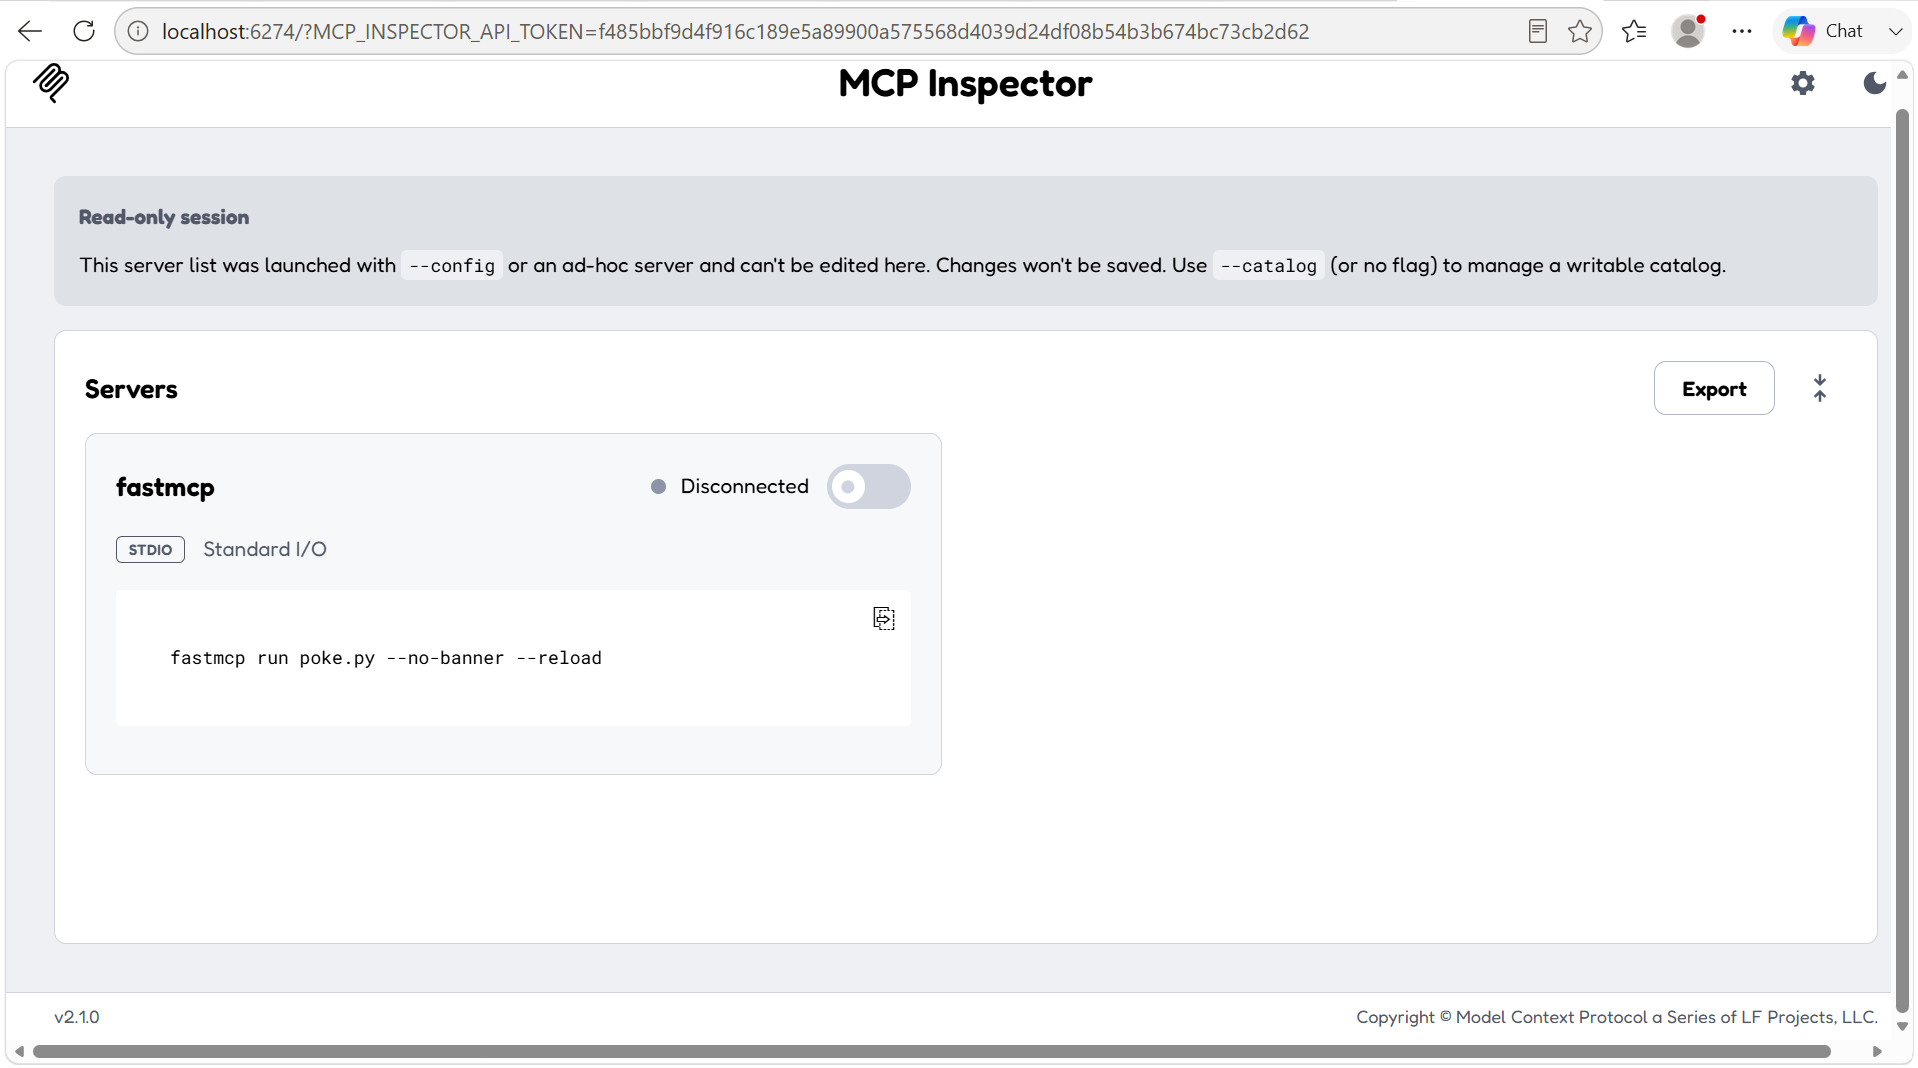

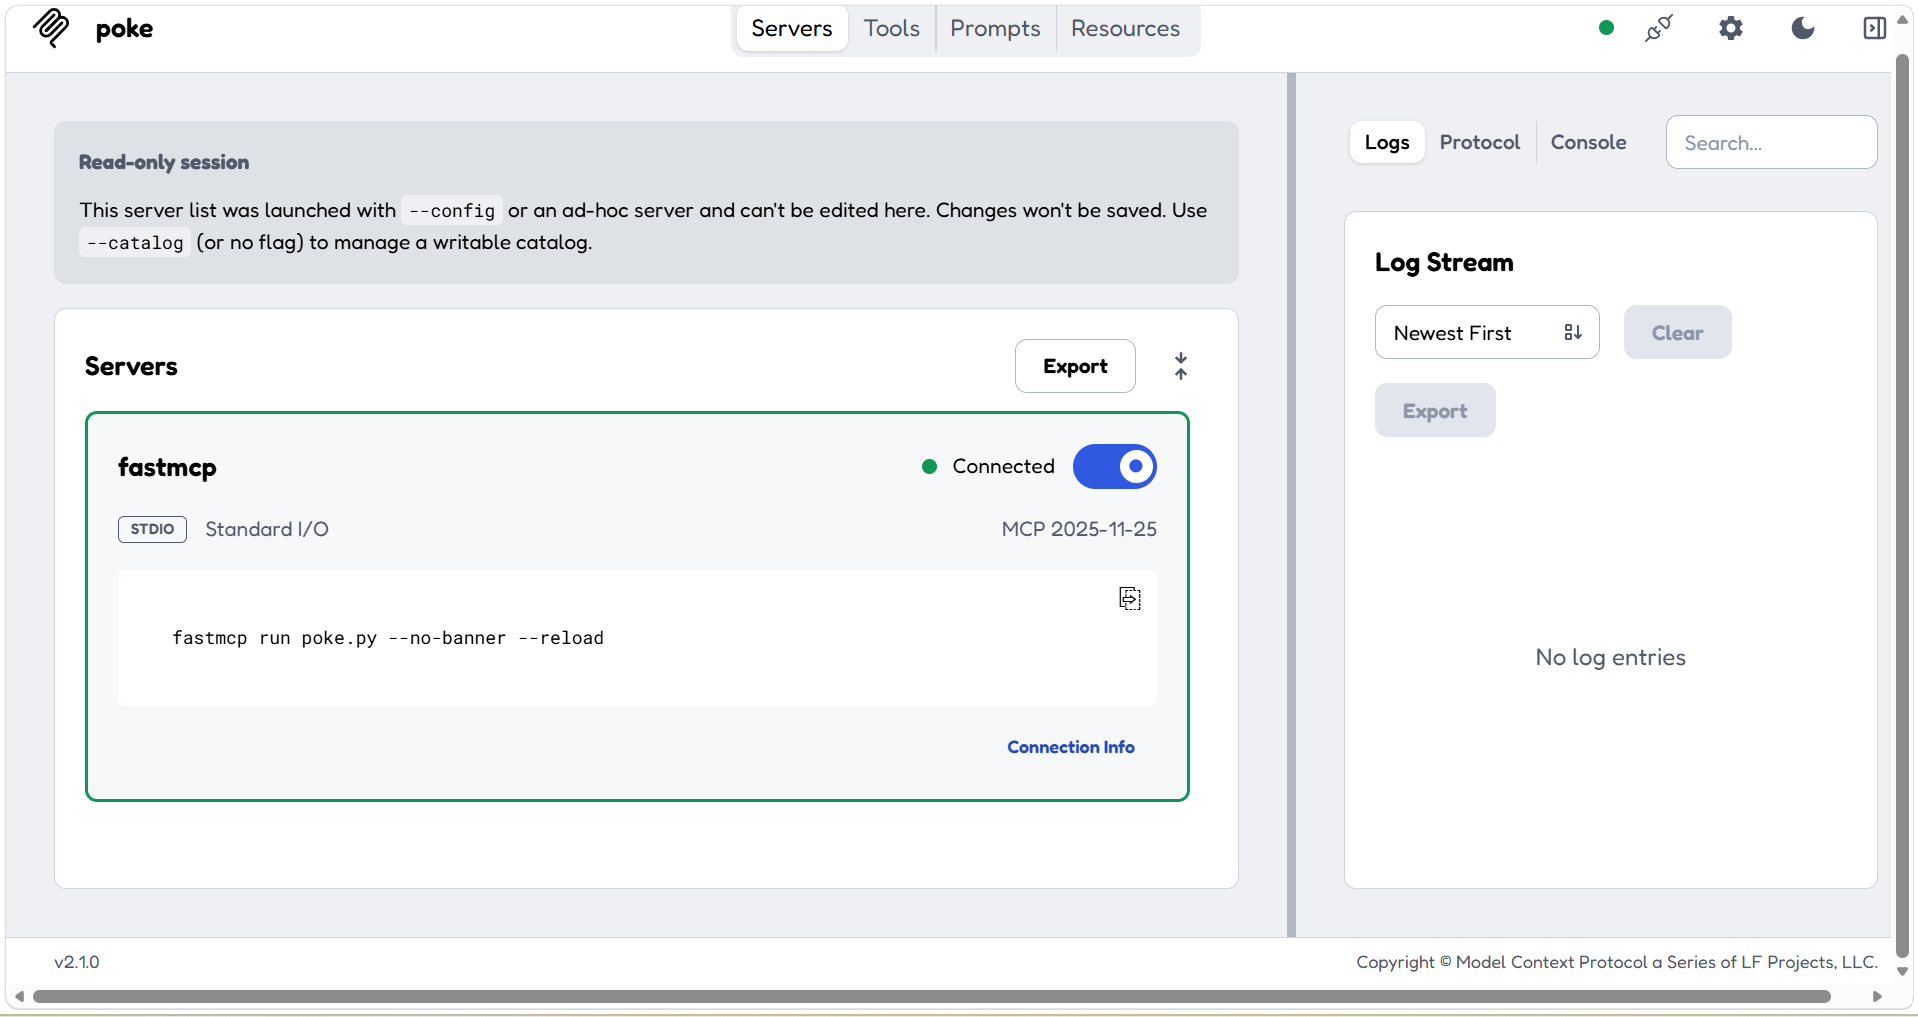

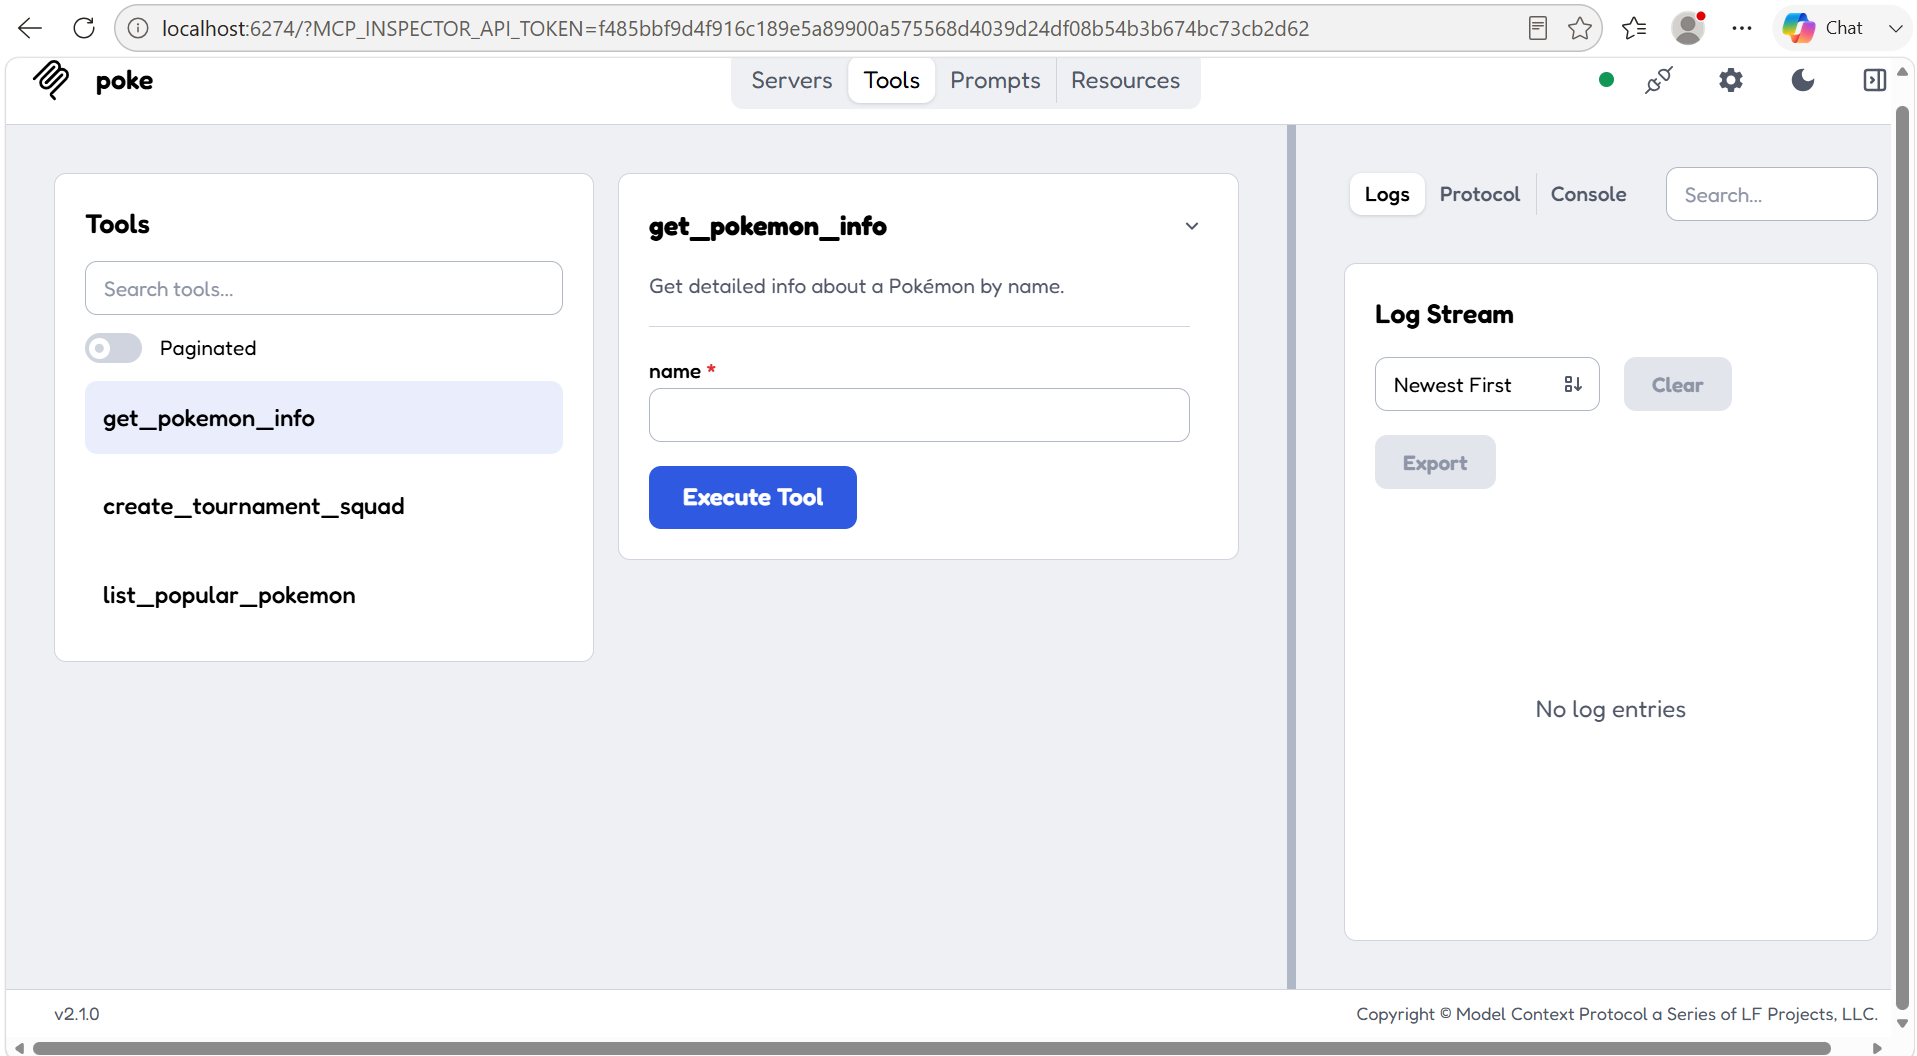

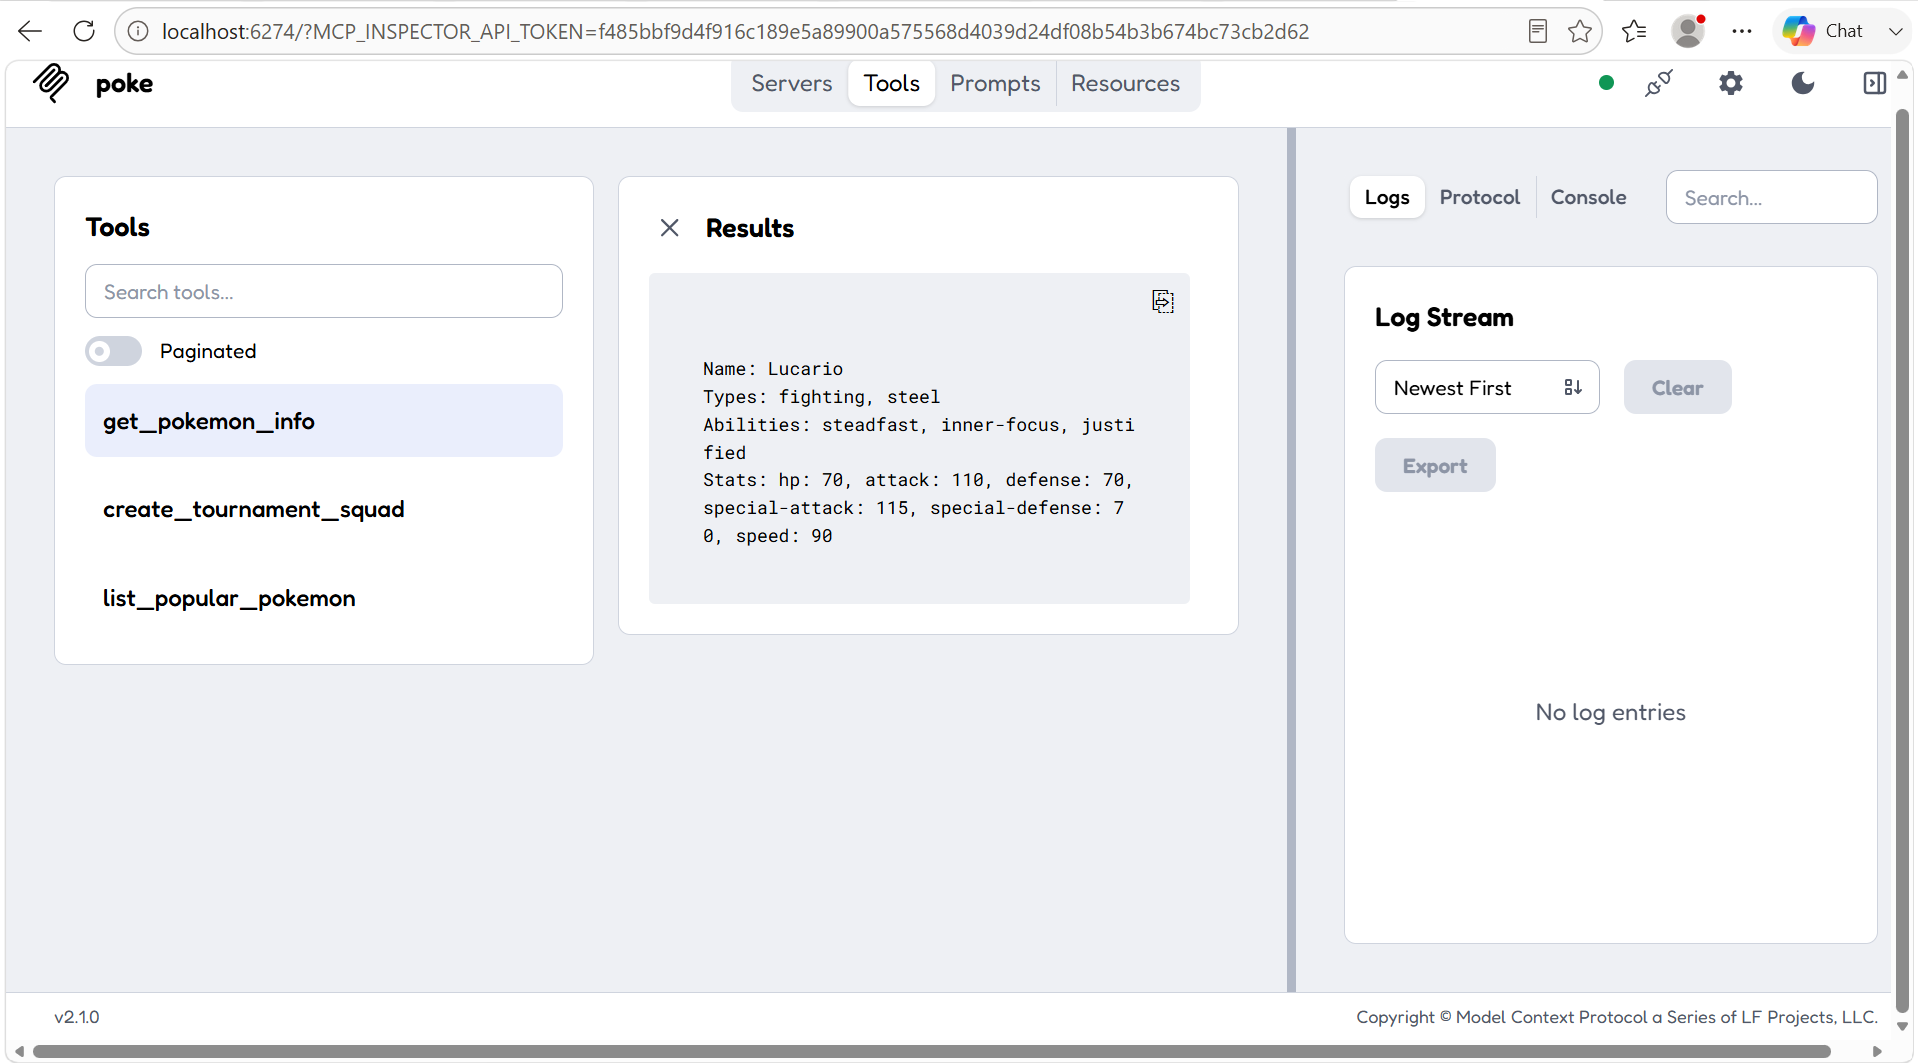

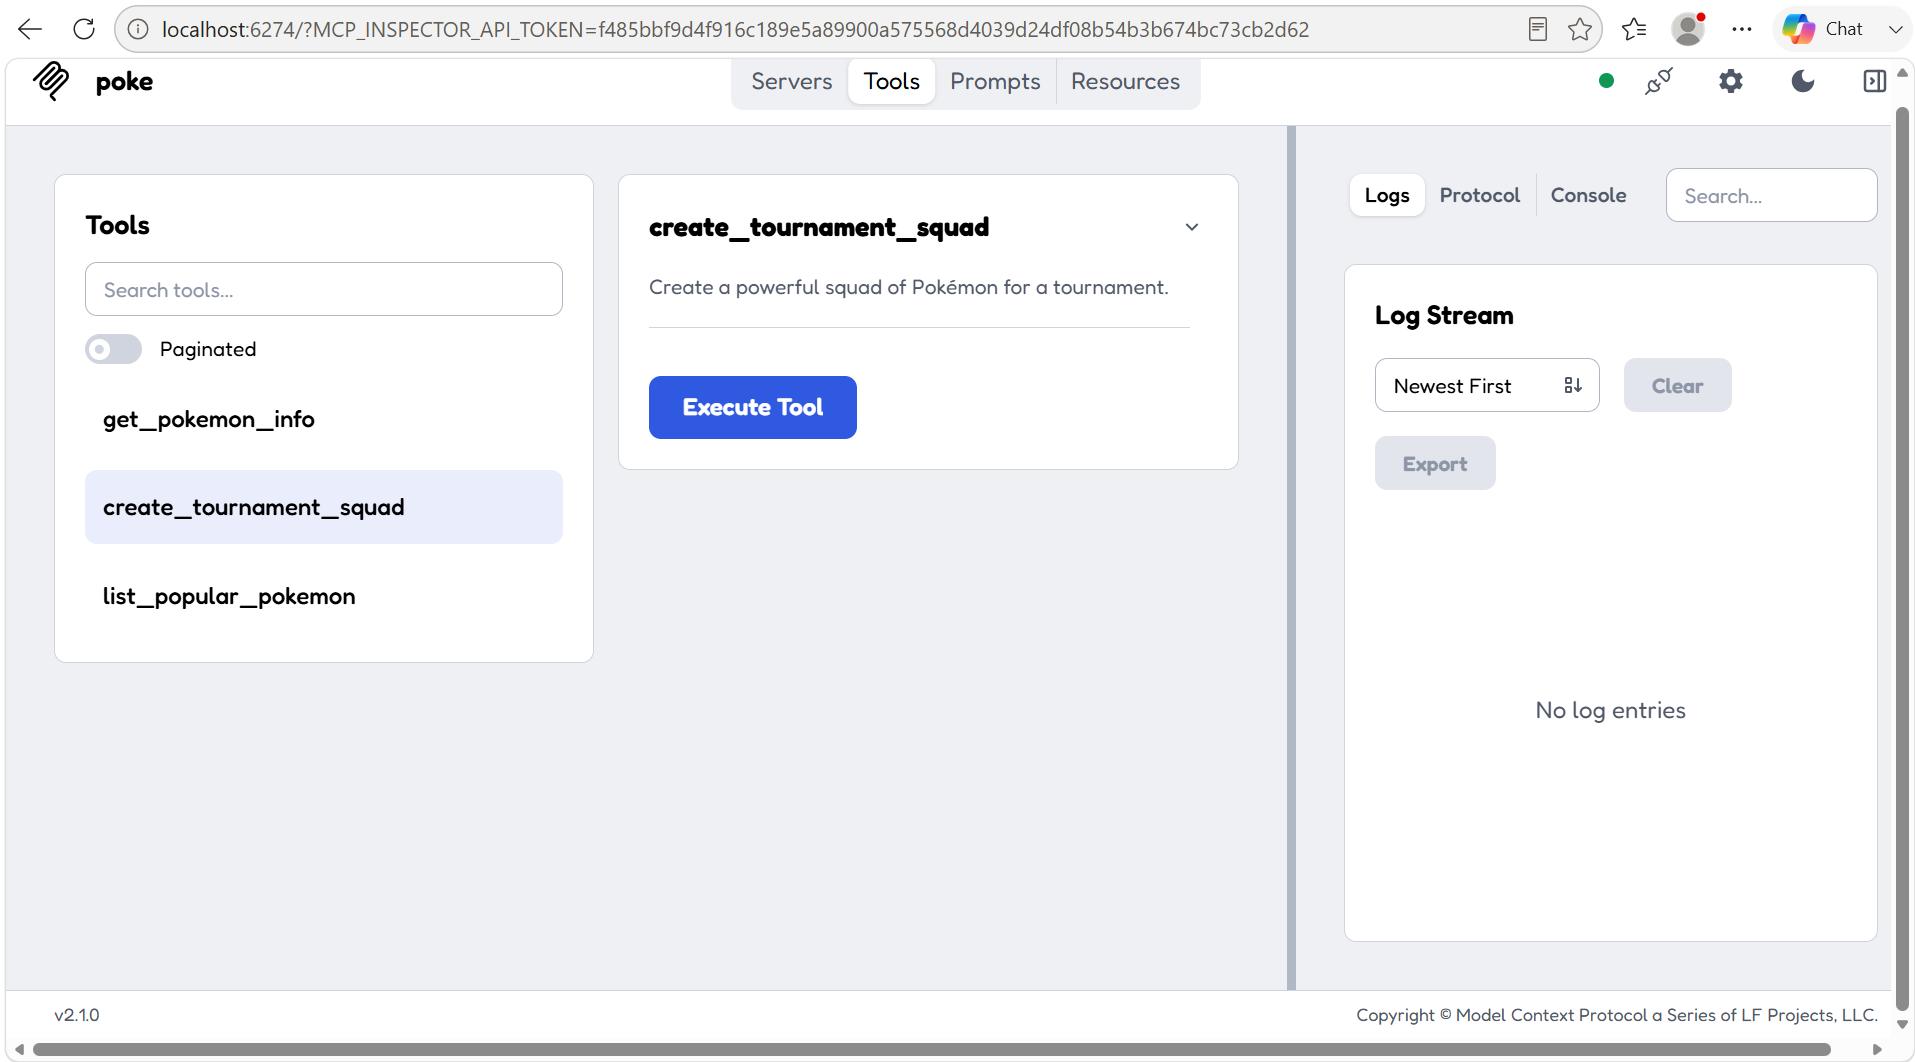

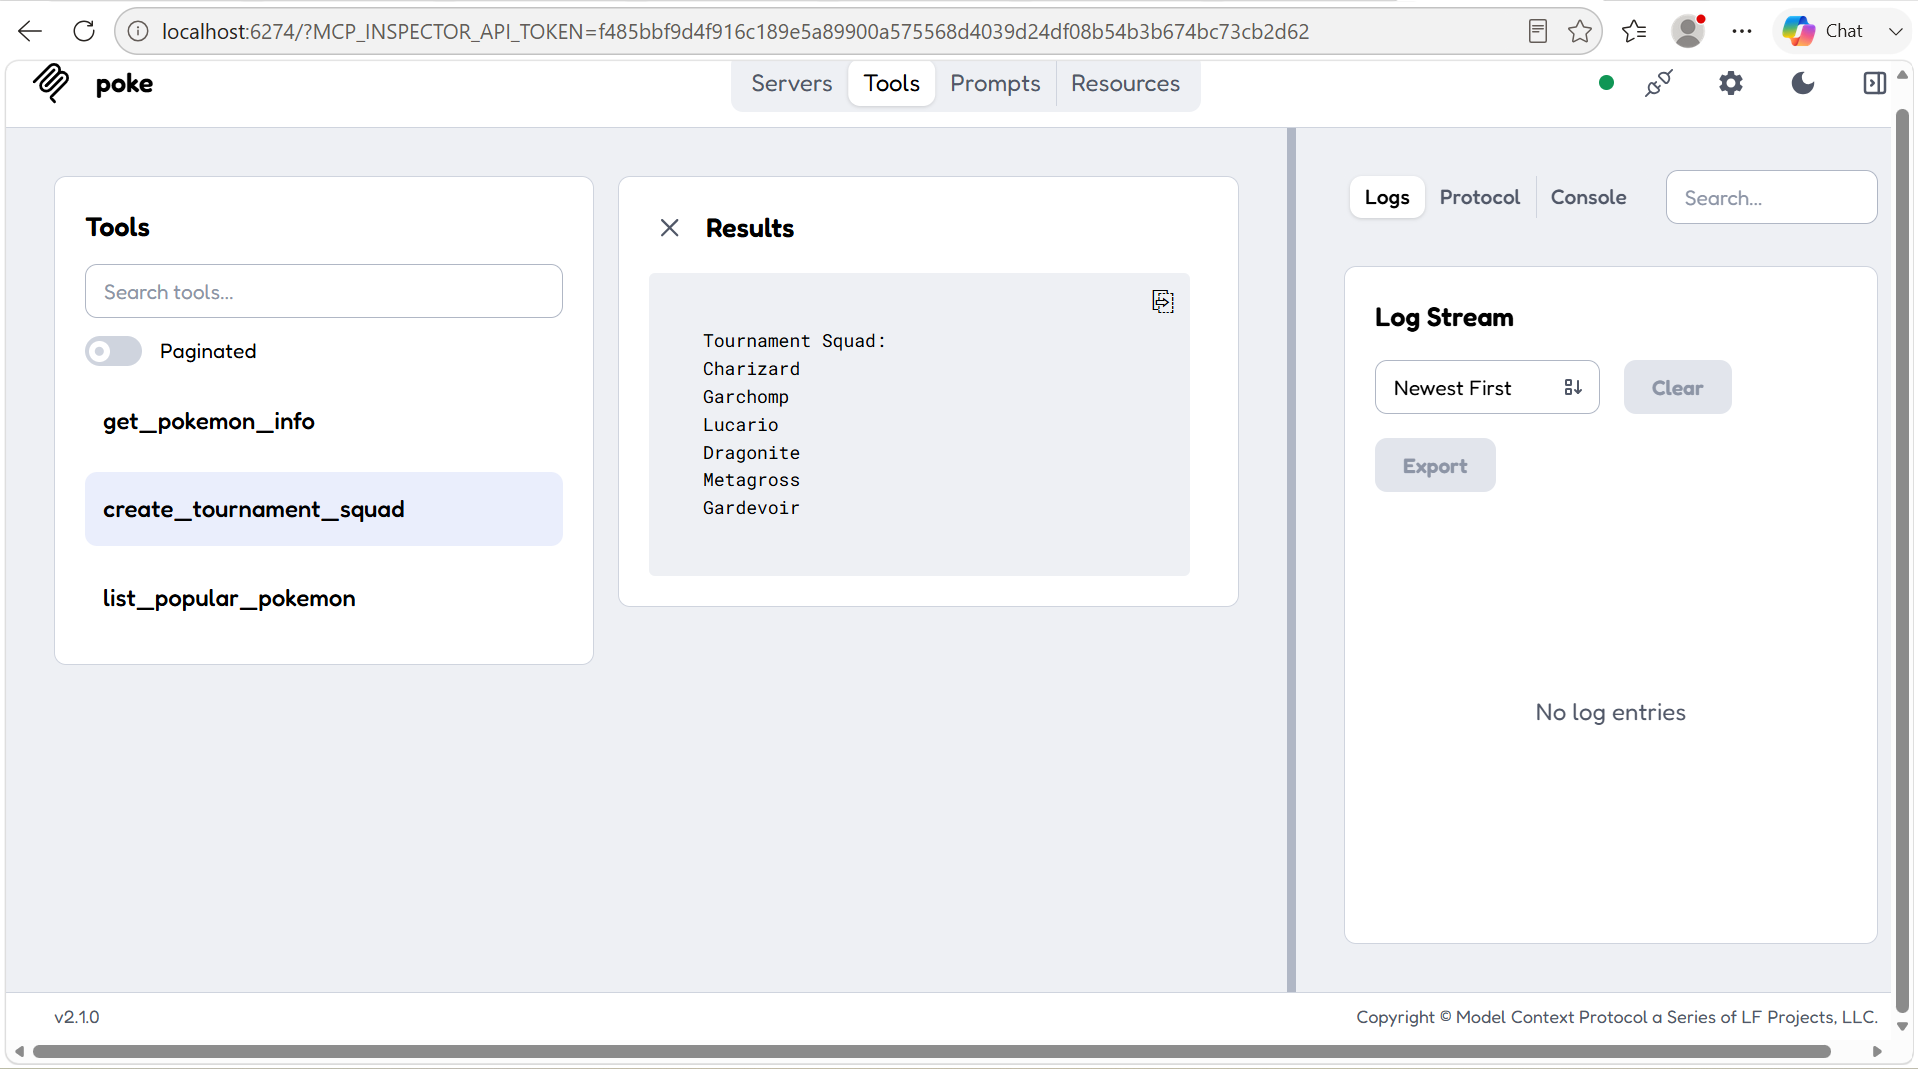

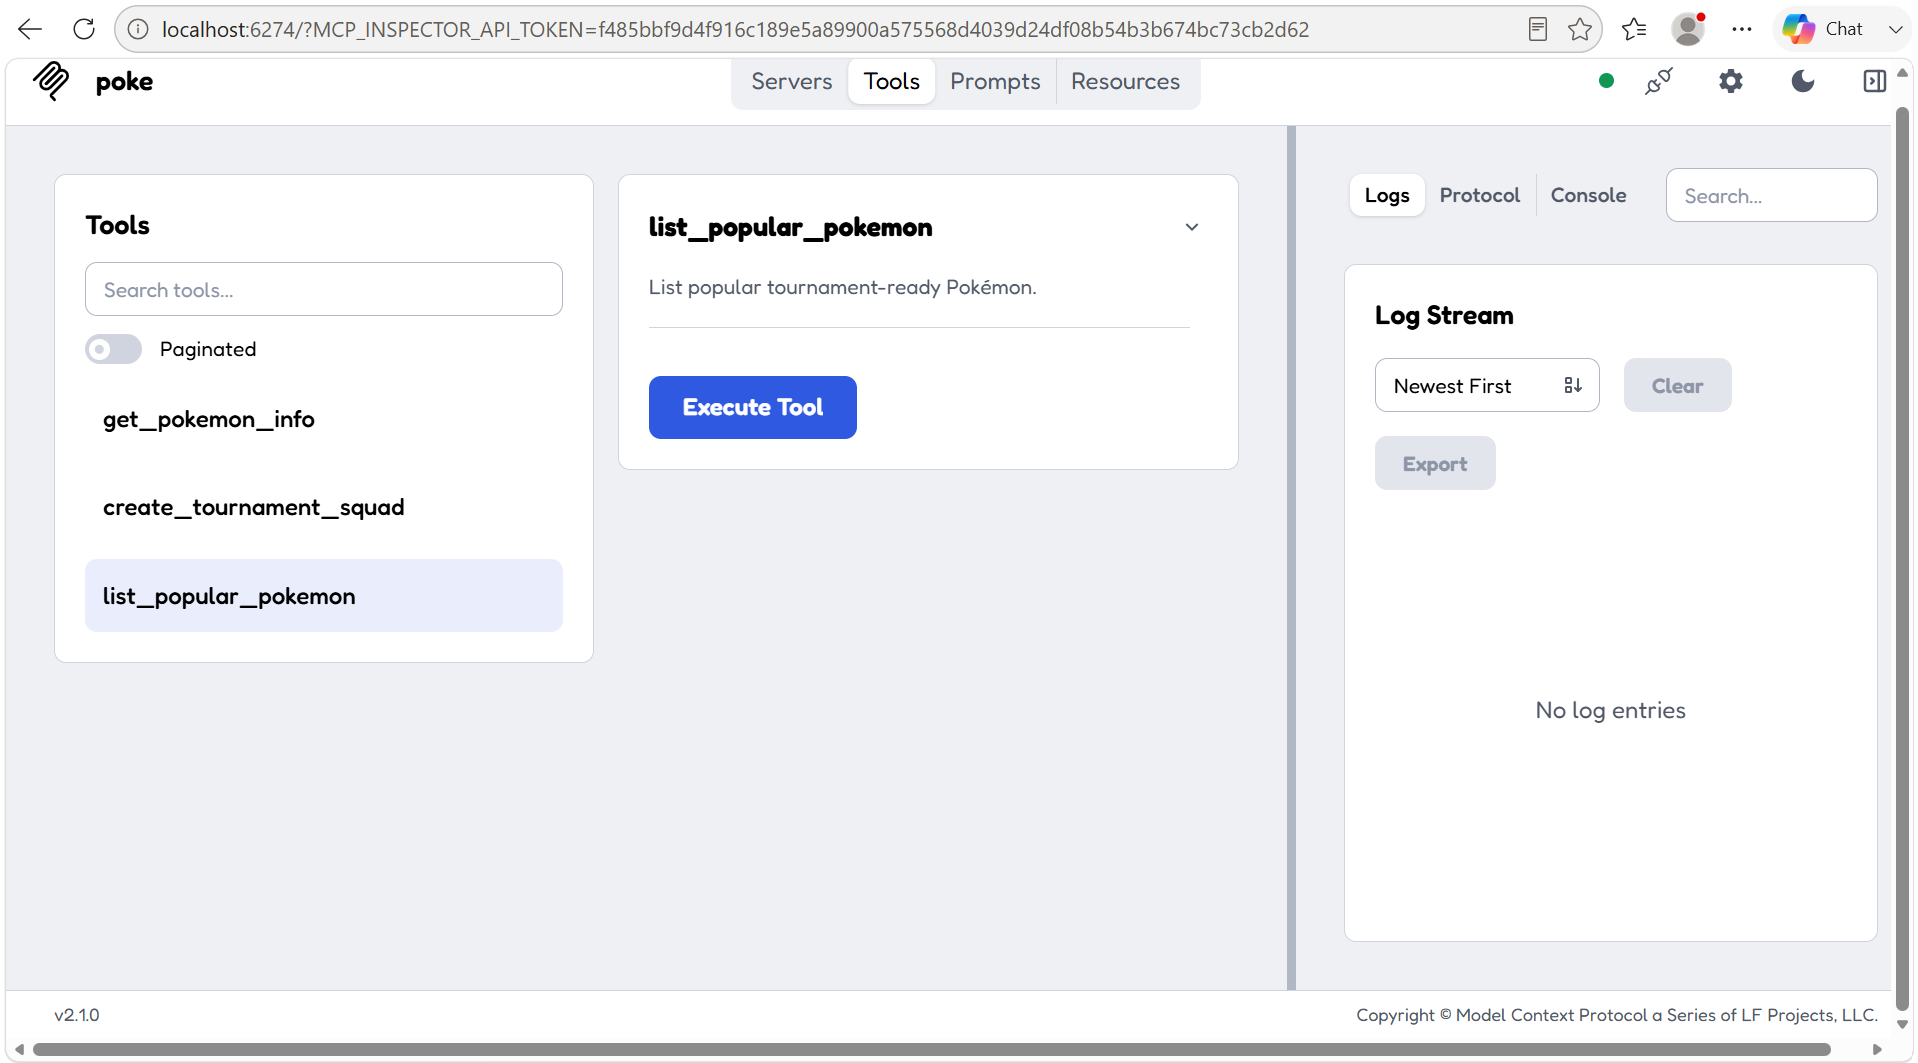

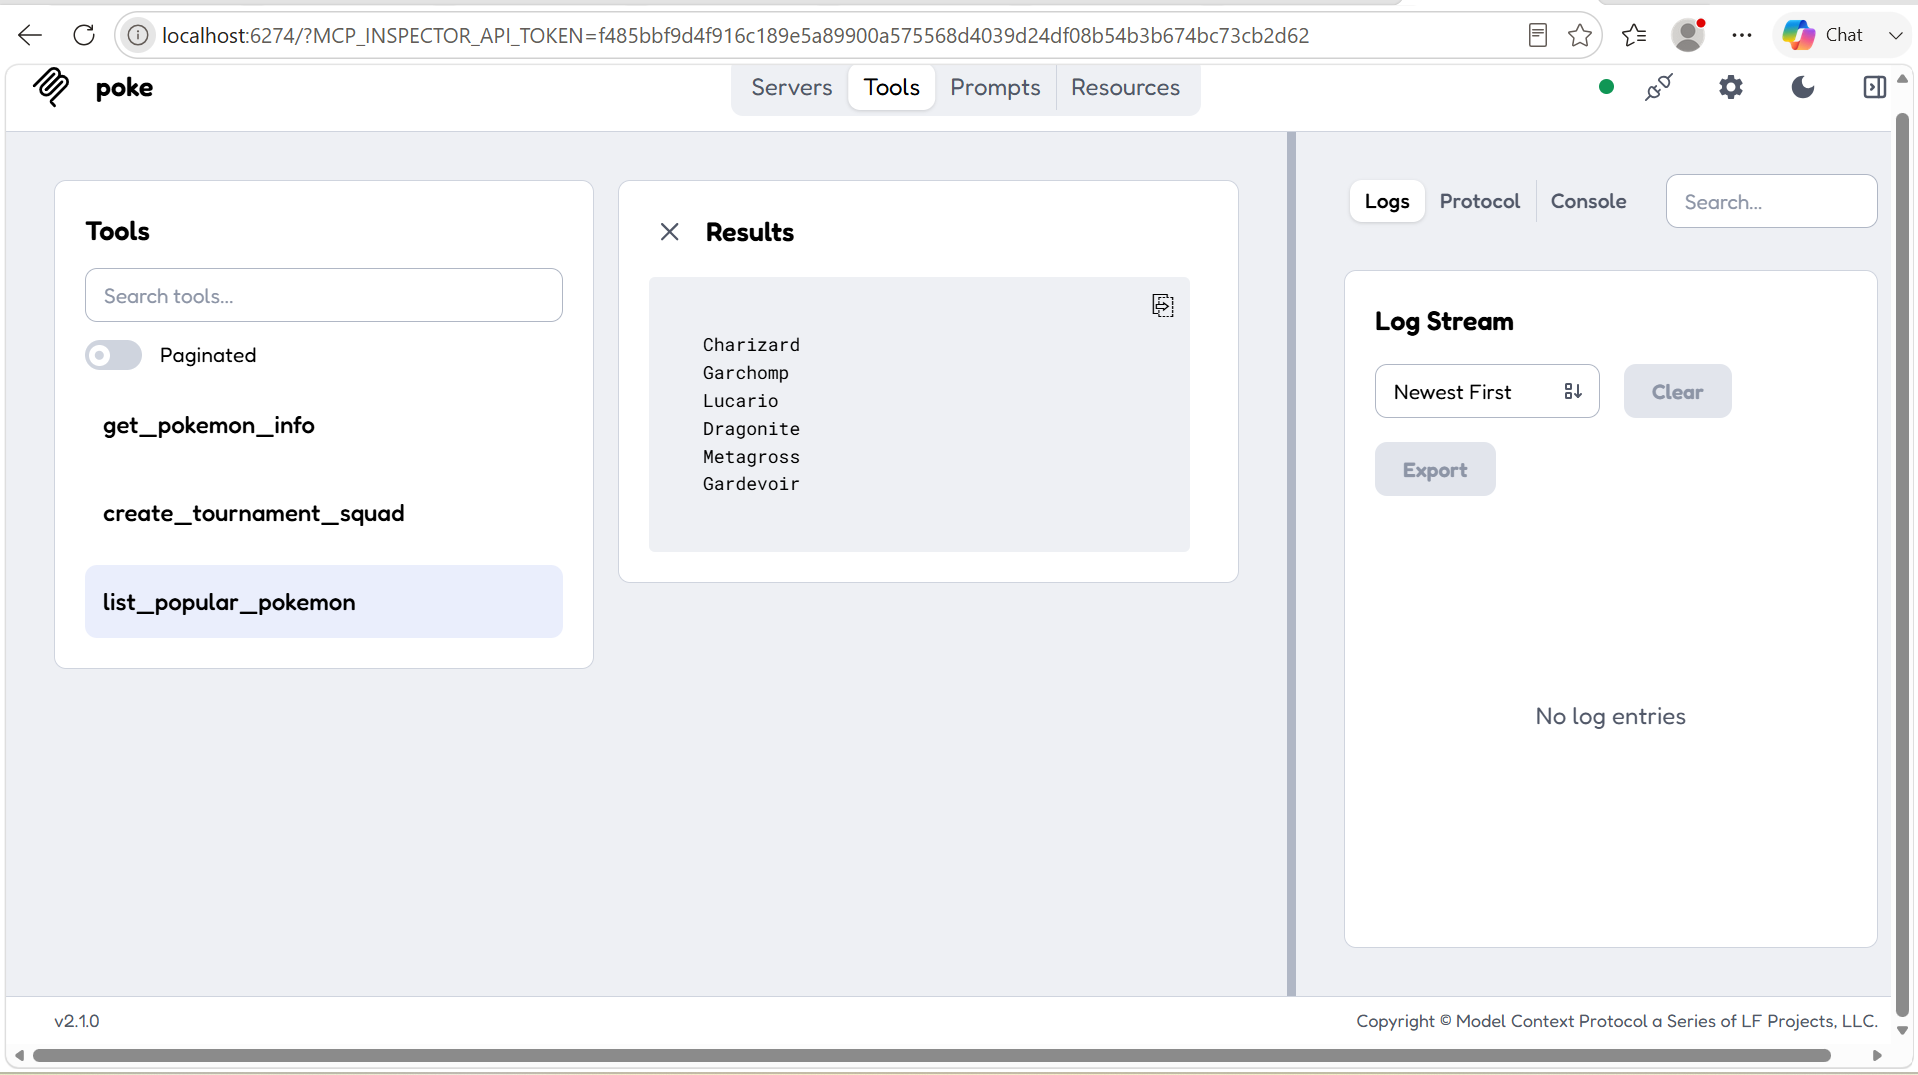